# India's Exam-Integrity Crisis — A Data-Driven Analysis (2004–2026)

This notebook is the analytical backbone behind the LinkedIn carousel of the same name.
It loads a hand-compiled record of **47 major Indian exam cancellations** between 2004 and 2026
and reproduces every headline figure used in the carousel, chart by chart.

Each section states a **finding**, shows the **code** that produces it, and plots a clean,
minimal chart. A closing **Limitations** section is deliberately included: several of the
headline numbers carry caveats that an honest reading has to keep in view.

> **Reproducibility:** `pip install -r requirements.txt`, then run top to bottom.
> The only input is `data/india_exam_cancellations_2004_2026.csv`.

## 1 · Setup and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("white")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# Shared palette — red is reserved for "the standout problem on this chart"
INK, RED, SLATE, AMBER, MUTED = "#1f2430", "#d42a34", "#2c3e57", "#c08a0f", "#cbc6b8"

df = pd.read_csv("data/india_exam_cancellations_2004_2026.csv")
print(f"{df.shape[0]} incidents · {df.shape[1]} columns · {df.cancellation_year.min()}–{df.cancellation_year.max()}")
df.head(3)

47 incidents · 26 columns · 2004–2026


,id,cancellation_month_year,cancellation_year,exam_year,exam_name,conducting_body,level,state_ut,exam_purpose,sector,...,candidates_note,party_in_power,coalition_then,coalition_now,govt_action,reexam_conducted,investigation,actions_taken,data_confidence,source
0,1,Apr-04,2004,2004,AIPMT 2004,CBSE,Central,Centre,Admission,Medical,...,~2.4 lakh appeared,"NDA (Vajpayee, BJP)",NDA,NDA,Reexam,Yes,Police,Leak detected after exam; re-conducted within ...,Medium,The Hindu / PTI archives
1,2,May-11,2011,2011,AIEEE 2011,CBSE,Central,Centre,Admission,Engineering,...,~12 lakh registered; delayed & fresh papers is...,"UPA (Manmohan Singh, INC)",UPA-INDIA,INDIA,Reschedule,Yes,STF,Delayed hours on 1 May 2011 after UP STF recov...,Medium,Times of India archive
2,3,Dec-13,2013,2013,Vyapam multi-exam scam,MPPEB,State,Madhya Pradesh,Recruitment & Admission,Multi,...,345 results (2013) & 634 MBBS degrees (SC 2017...,BJP (Shivraj Singh Chouhan),NDA,NDA,Probe,No,CBI,"STF->SIT->CBI; 2,000+ arrests; SC cancelled 63...",Low,Supreme Court judgment (2017)


In [2]:
# Columns available for analysis
list(df.columns)

['id',
 'cancellation_month_year',
 'cancellation_year',
 'exam_year',
 'exam_name',
 'conducting_body',
 'level',
 'state_ut',
 'exam_purpose',
 'sector',
 'cause',
 'stage',
 'annulment_type',
 'applied',
 'appeared',
 'aspirants_impacted',
 'candidates_note',
 'party_in_power',
 'coalition_then',
 'coalition_now',
 'govt_action',
 'reexam_conducted',
 'investigation',
 'actions_taken',
 'data_confidence',
 'source']

### Data dictionary (key fields)

| Column | Meaning |
|---|---|
| `cancellation_year` | Year the exam was cancelled / annulled |
| `exam_name`, `conducting_body`, `level` | What was cancelled and who ran it |
| `state_ut` | Jurisdiction (`Centre` = central bodies: NEET, SSC, UGC-NET, CBSE …) |
| `exam_purpose` | Recruitment / Admission / Eligibility / Board |
| `sector` | Domain of the exam (Police, Teaching, Medical …) |
| `cause` | Why it was cancelled (Paper leak, OMR manipulation …) |
| `aspirants_impacted` | Estimated candidates affected |
| `coalition_then` | Ruling national coalition at the time of cancellation |
| `data_confidence`, `source` | Confidence flag and per-row source |

Every row is a **publicly reported** incident; `source` records where it came from and
`data_confidence` flags how firm the figures are.

In [3]:
# Data-confidence mix — how firm is the underlying record?
df["data_confidence"].value_counts()

data_confidence
Medium    31
High      11
Low        5
Name: count, dtype: int64

## 2 · Finding 1 — The crisis is recent

Cancellations existed across the whole period, but they cluster hard in the most recent years.

In [4]:
N = len(df)
years = range(df.cancellation_year.min(), df.cancellation_year.max() + 1)
counts = df.cancellation_year.value_counts().reindex(years, fill_value=0).sort_index()

# Two defensible "last 5 years" windows
w_2022 = counts.loc[2022:].sum()   # 2022–2026 inclusive = literal last 5 calendar years
w_2021 = counts.loc[2021:].sum()   # 2021–2026 = the full post-surge window
print(f"2022–2026: {w_2022}/{N} = {100*w_2022/N:.1f}%   <- used in the carousel ('last 5 years')")
print(f"2021–2026: {w_2021}/{N} = {100*w_2021/N:.1f}%   <- surge window (6 years)")
print(f"Peak year: 2022 with {counts.loc[2022]} cancellations")

2022–2026: 28/47 = 59.6%   <- used in the carousel ('last 5 years')
2021–2026: 32/47 = 68.1%   <- surge window (6 years)
Peak year: 2022 with 10 cancellations


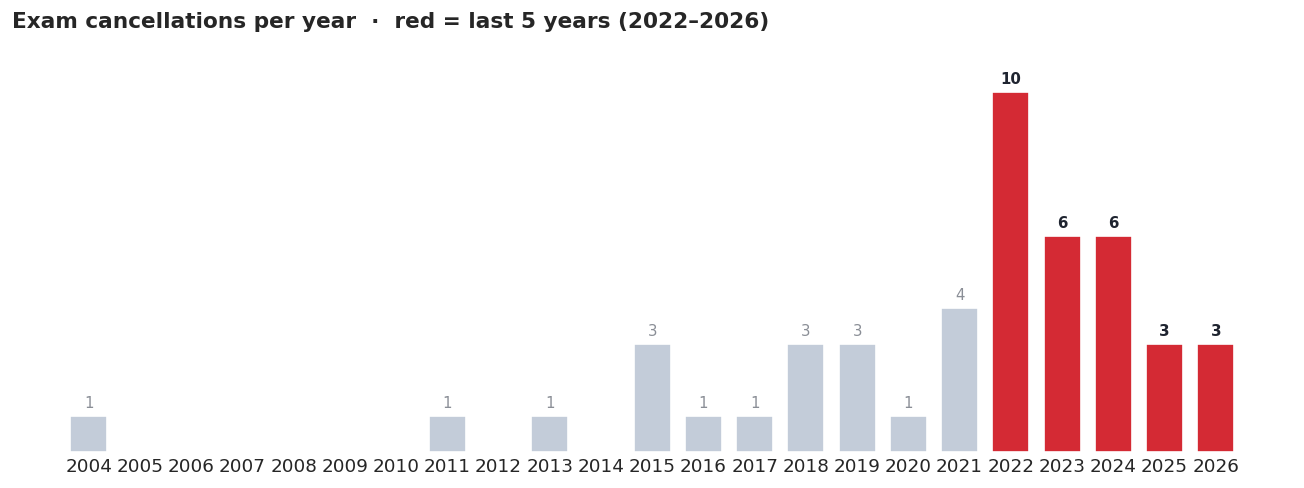

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
colors = [RED if y >= 2022 else "#c3ccd9" for y in counts.index]
ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.72)
for x, v in enumerate(counts.values):
    if v:
        ax.text(x, v + 0.15, str(v), ha="center", va="bottom",
                fontsize=9, fontweight="bold" if counts.index[x] >= 2022 else "normal",
                color=INK if counts.index[x] >= 2022 else "#8a8e96")
ax.set_yticks([]); ax.set_xlabel("")
ax.tick_params(axis="x", length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.margins(y=0.15)
ax.set_title("Exam cancellations per year  ·  red = last 5 years (2022–2026)", loc="left")
plt.tight_layout(); plt.show()

## 3 · Finding 2 — Nearly 8 in 10 were paper leaks

The dominant failure mode is not cheating in the hall — it is the question paper escaping beforehand.

In [6]:
cause = df["cause"].value_counts()
cause_pct = (100 * cause / N).round(1)
pd.DataFrame({"count": cause, "share_%": cause_pct})

,count,share_%
cause,,
Paper leak,37,78.7
OMR manipulation,4,8.5
Impersonation,2,4.3
Electronic cheating,2,4.3
Cash-for-jobs,1,2.1
Mark tampering,1,2.1


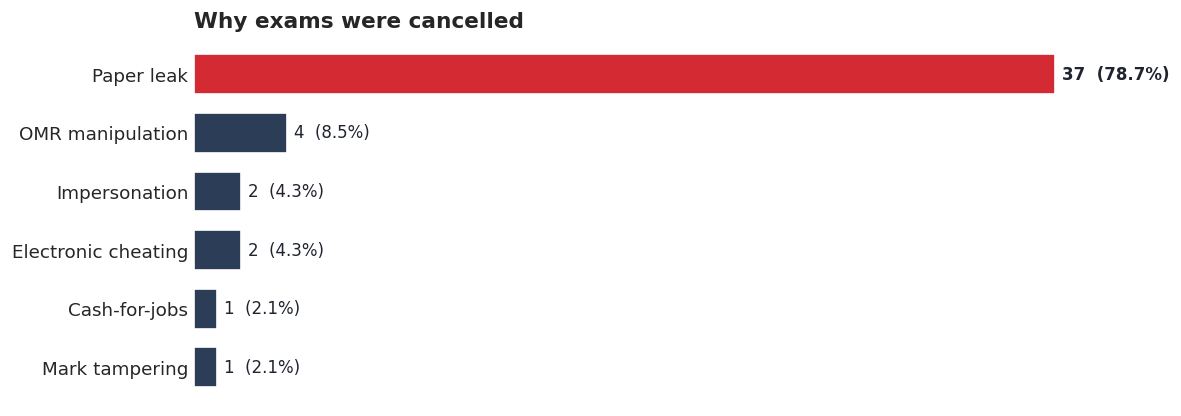

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.6))
order = cause.index[::-1]
vals = cause[order].values
colors = [RED if k == "Paper leak" else SLATE for k in order]
ax.barh(order, vals, color=colors, height=0.68)
for i, k in enumerate(order):
    ax.text(vals[i] + 0.3, i, f"{cause[k]}  ({cause_pct[k]}%)", va="center", fontsize=10,
            color=INK, fontweight="bold" if k == "Paper leak" else "normal")
ax.set_xticks([]); 
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Why exams were cancelled", loc="left")
ax.margins(x=0.12); plt.tight_layout(); plt.show()

## 4 · Finding 3 — The people who pay

Weighting by **aspirants impacted** (not incident count) shows where the human cost lands:
overwhelmingly on people sitting recruitment exams for government jobs.

In [8]:
total_asp = int(df["aspirants_impacted"].sum())
print(f"Total aspirants impacted across all incidents: {total_asp:,}  (~{total_asp/1e7:.2f} crore)")

imp = df.groupby("exam_purpose")["aspirants_impacted"].sum()
imp = imp[imp > 0].sort_values(ascending=False)
imp_pct = (100 * imp / imp.sum()).round(2)
pd.DataFrame({"aspirants": imp.astype(int), "share_%": imp_pct})

Total aspirants impacted across all incidents: 31,490,595  (~3.15 crore)


,aspirants,share_%
exam_purpose,,
Recruitment,19008514,60.36
Admission,6746079,21.42
Eligibility,5136002,16.31
Board,600000,1.91


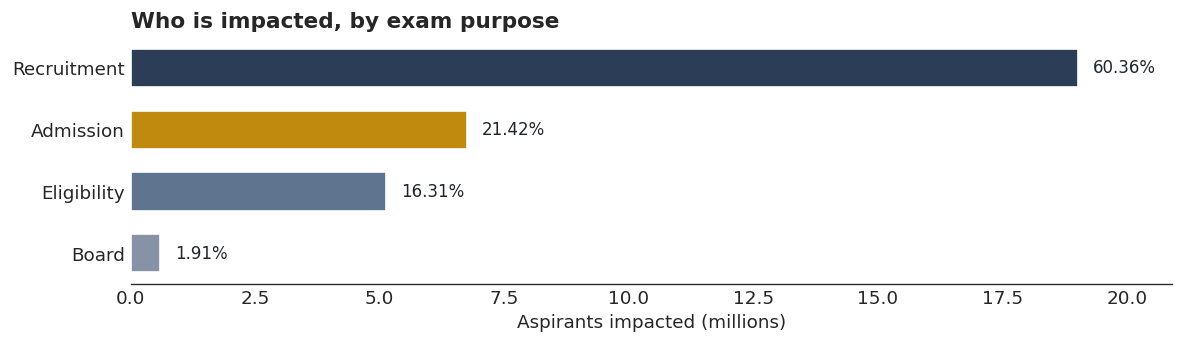

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.0))
order = imp.index[::-1]
vals = (imp[order] / 1e6).values
colors = {"Recruitment": SLATE, "Admission": AMBER, "Eligibility": "#5e748f", "Board": "#8792a6"}
ax.barh(order, vals, color=[colors.get(k, MUTED) for k in order], height=0.62)
for i, k in enumerate(order):
    ax.text(vals[i] + 0.3, i, f"{imp_pct[k]}%", va="center", fontsize=10, color=INK)
ax.set_xlabel("Aspirants impacted (millions)")
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Who is impacted, by exam purpose", loc="left")
ax.margins(x=0.10); plt.tight_layout(); plt.show()

## 5 · Finding 4 — The damage concentrates in a few sectors

**Transparency note:** the carousel says *"80% hit six sectors, led by police, teaching and
civil services."* Below is exactly why that phrasing is used — the three named leaders alone are
~49%; it takes the **top six** sectors to reach 80%.

In [10]:
sector = df["sector"].value_counts()
top3 = sector.head(3).sum()
top6 = sector.head(6).sum()
print(f"Police + Teaching + Civil Services: {top3}/{N} = {100*top3/N:.1f}%")
print(f"Top six sectors:                    {top6}/{N} = {100*top6/N:.1f}%  <- the '80%'")
sector

Police + Teaching + Civil Services: 24/47 = 51.1%
Top six sectors:                    38/47 = 80.9%  <- the '80%'


sector
Police            10
Teaching           8
Multi              6
Civil Services     5
Clerical           5
Medical            4
Engineering        3
Agriculture        1
School-Board       1
PSU/Technical      1
Defence            1
Forest             1
Revenue            1
Name: count, dtype: int64

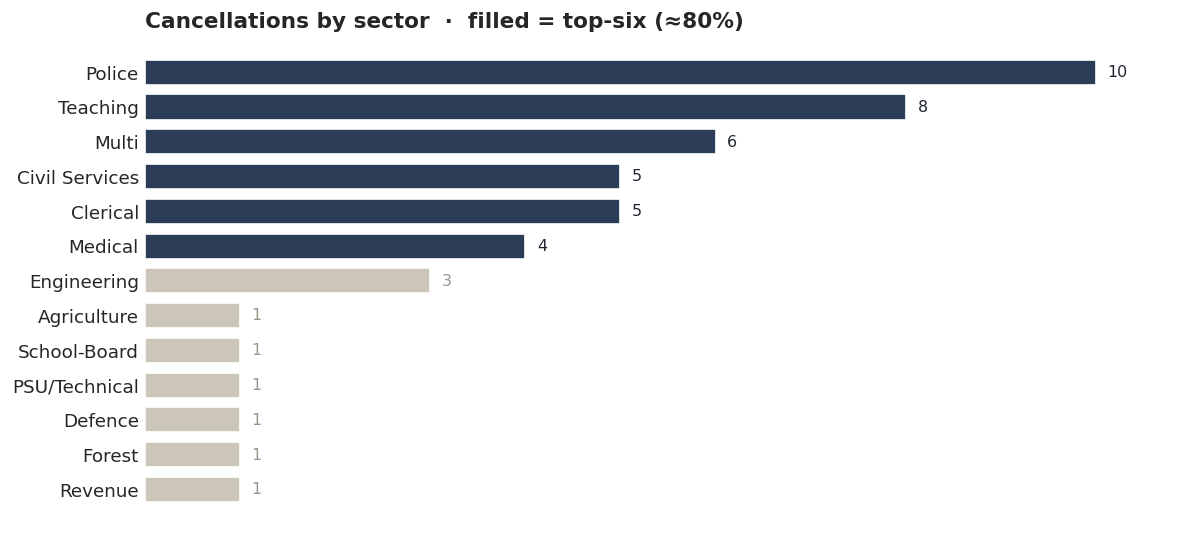

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.6))
order = sector.index[::-1]
top6_set = set(sector.head(6).index)
colors = [SLATE if k in top6_set else MUTED for k in order]
ax.barh(order, sector[order].values, color=colors, height=0.72)
for i, k in enumerate(order):
    ax.text(sector[k] + 0.12, i, str(sector[k]), va="center", fontsize=9.5,
            color=INK if k in top6_set else "#9a968b")
ax.set_xticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Cancellations by sector  ·  filled = top-six (≈80%)", loc="left")
ax.margins(x=0.08); plt.tight_layout(); plt.show()

## 6 · Finding 5 — Nationwide, but the Centre is the single largest bucket

**Caveat baked into this chart:** `Centre` is not a state. It aggregates *central* bodies
(NEET, SSC, UGC-NET, CBSE) that operate nationally, so it sits above every individual state by
construction. Read it as *"which conducting jurisdiction,"* not *"which state is worst."*

In [12]:
state = df["state_ut"].value_counts()
print(f"Distinct jurisdictions hit: {state.size}  (incl. 'Centre')")
print(f"Centre: {state['Centre']}  ·  top state: {state.drop('Centre').idxmax()} ({state.drop('Centre').max()})")
state

Distinct jurisdictions hit: 17  (incl. 'Centre')
Centre: 12  ·  top state: Bihar (5)


state_ut
Centre              12
Bihar                5
Rajasthan            5
Uttar Pradesh        4
Gujarat              3
Jammu & Kashmir      3
Assam                2
Himachal Pradesh     2
Maharashtra          2
Uttarakhand          2
Madhya Pradesh       1
Haryana              1
Karnataka            1
Odisha               1
Telangana            1
Jharkhand            1
West Bengal          1
Name: count, dtype: int64

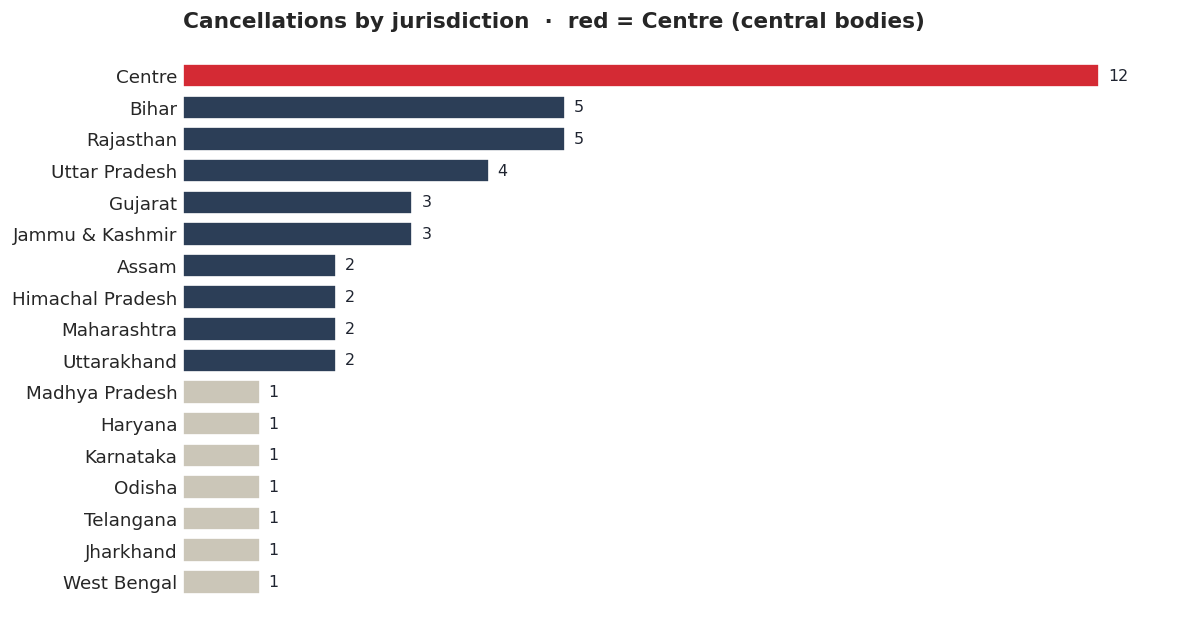

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.4))
order = state.index[::-1]
colors = [RED if k == "Centre" else SLATE if v > 1 else MUTED for k, v in state[order].items()]
ax.barh(order, state[order].values, color=colors, height=0.74)
for i, k in enumerate(order):
    ax.text(state[k] + 0.12, i, str(state[k]), va="center", fontsize=9.5, color=INK)
ax.set_xticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Cancellations by jurisdiction  ·  red = Centre (central bodies)", loc="left")
ax.margins(x=0.08); plt.tight_layout(); plt.show()

## 7 · Finding 6 — Two-thirds occurred under NDA-led governments

**Read this one carefully.** The share of cancellations under a coalition partly reflects how
**long that coalition was in power** across 2004–2026. The tally below is real; a causal reading
("one side is to blame") is *not* supported by this data alone. The carousel keeps this stat but
pairs it with that caveat.

In [14]:
coal = df["coalition_then"].value_counts()
coal_pct = (100 * coal / N).round(2)
pd.DataFrame({"count": coal, "share_%": coal_pct})

,count,share_%
coalition_then,,
NDA,31,65.96
UPA-INDIA,12,25.53
Regional,3,6.38
INDIA,1,2.13


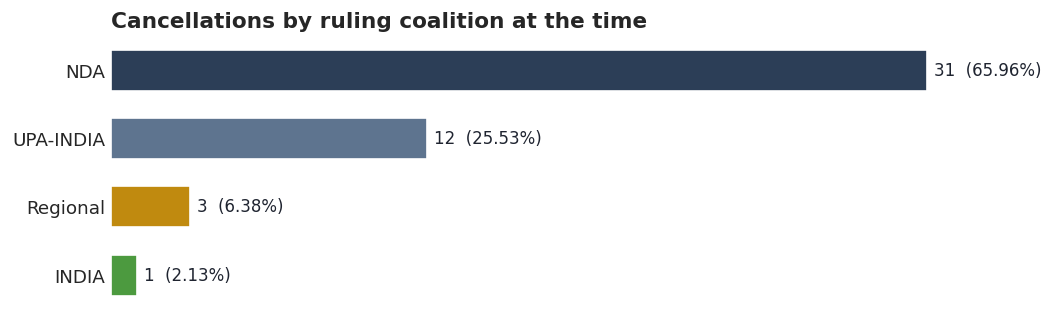

In [15]:
fig, ax = plt.subplots(figsize=(9, 2.8))
order = coal.index[::-1]
cmap = {"NDA": SLATE, "UPA-INDIA": "#5e748f", "Regional": AMBER, "INDIA": "#4c9a3f"}
ax.barh(order, coal[order].values, color=[cmap.get(k, MUTED) for k in order], height=0.6)
for i, k in enumerate(order):
    ax.text(coal[k] + 0.25, i, f"{coal[k]}  ({coal_pct[k]}%)", va="center", fontsize=10, color=INK)
ax.set_xticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Cancellations by ruling coalition at the time", loc="left")
ax.margins(x=0.14); plt.tight_layout(); plt.show()

## 8 · Limitations & honest caveats

These are the things a careful reader should keep in mind — and that a critic will raise first.

1. **Reporting bias in the early years.** The sparse counts before ~2015 almost certainly
   reflect *thinner media coverage and record-keeping*, not a cleaner system. The upward trend is
   partly a real worsening and partly better documentation — the two can't be fully separated here.
2. **`Centre` is a category, not a state.** It out-tops every state by construction (it pools
   national bodies). The geography chart answers "which jurisdiction," not "which state is worst."
3. **Coalition share ≈ time in power.** Finding 6 is an association, not a verdict. Attribution of
   blame would require normalising by years in office and by exams conducted — out of scope here.
4. **"80% / six sectors" vs "police, teaching, civil services."** The three named leaders are ~49%;
   it takes six sectors to reach 80%. The wording is chosen to be true to both.
5. **Two valid "last 5 years."** 2022–2026 = ~60%; 2021–2026 = ~68%. The carousel uses 60%.
6. **Counts vs severity.** Incident counts treat a 24-lakh-aspirant national leak the same as a
   single district reschedule. `aspirants_impacted` (Finding 3) is the better severity lens.

None of these overturn the headline story — cancellations are frequent, recent, leak-driven, and
concentrated on government-job aspirants — but they bound how far each individual number can be pushed.

---
*Charts here are the exploratory analysis. The polished LinkedIn carousel (`carousel/`) was built
separately in HTML/SVG for print-grade typography, but every figure traces back to the cells above.*